In [100]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np


In [101]:
data = pd.read_csv('Indoor_Plant_Health_and_Growth_Factors.csv')
data = pd.DataFrame(data)
data.head(20)

,Plant_ID,Height_cm,Leaf_Count,New_Growth_Count,Health_Notes,Watering_Amount_ml,Watering_Frequency_days,Sunlight_Exposure,Room_Temperature_C,Humidity_%,Fertilizer_Type,Fertilizer_Amount_ml,Pest_Presence,Pest_Severity,Soil_Moisture_%,Soil_Type,Health_Score
0,Sansevieria cylindrica,17.39,17,8,Yellowing leaves,205,3,3h direct morning sun,21.7,77.5,Organic,82,Fungus gnats,Moderate,51.9,Clay,1
1,Aloe vera,9.84,31,9,NaN,191,1,3h direct morning sun,22.6,68.9,NaN,91,Aphids,Low,28.2,Loamy,2
2,Ficus lyrata,19.82,40,8,Brittle leaves,477,5,Indirect light all day,17.2,44.3,Liquid feed,90,NaN,High,13.6,Sandy,1
3,Monstera deliciosa,37.08,11,1,New bud,207,1,Low light corner,25.0,72.2,Compost,76,Fungus gnats,Low,38.4,Sandy,4
4,Ficus lyrata,2.96,26,3,Wilting,465,2,Filtered sunlight through curtain,23.2,51.6,Compost,37,Fungus gnats,Low,37.9,Peaty,1
5,Ficus lyrata,14.63,14,6,NaN,375,6,Low light corner,26.9,71.4,Chemical,42,Whiteflies,High,52.5,Clay,4
6,Calathea orbifolia,23.73,43,1,Strong stem,420,1,3h direct morning sun,20.7,71.1,Liquid feed,20,Fungus gnats,NaN,59.8,Silty,1
7,Anthurium andraeanum,16.23,19,0,Strong stem,393,4,Filtered sunlight through curtain,22.1,39.4,NaN,90,Spider mites,NaN,35.4,Clay,1
8,Ficus lyrata,19.73,19,2,NaN,311,1,6h full sun,19.5,65.1,Liquid feed,61,NaN,Low,27.3,Clay,5
9,Anthurium andraeanum,19.88,8,3,NaN,332,3,Filtered sunlight through curtain,21.0,44.5,Liquid feed,45,NaN,High,19.3,Clay,2


Drop all the non relevant data.

The remaining data will be the sensor readings (light, temprature, soil moisture, humidity) in addition to the watering frequency that can be measured.

In [102]:
df = data.copy()
df = df.drop(columns=['Plant_ID', 'Height_cm', 'Leaf_Count', 'New_Growth_Count', 'Health_Notes', 'Fertilizer_Type', 'Fertilizer_Amount_ml', 'Pest_Presence', 'Pest_Severity', 'Soil_Type', 'Health_Score'])
df.head()

,Watering_Amount_ml,Watering_Frequency_days,Sunlight_Exposure,Room_Temperature_C,Humidity_%,Soil_Moisture_%
0,205,3,3h direct morning sun,21.7,77.5,51.9
1,191,1,3h direct morning sun,22.6,68.9,28.2
2,477,5,Indirect light all day,17.2,44.3,13.6
3,207,1,Low light corner,25.0,72.2,38.4
4,465,2,Filtered sunlight through curtain,23.2,51.6,37.9


Translate the Sunligh exposure into light range, by giving each category a numeric range

In [103]:

light_ranges = {
    "Low light corner": (0, 200),
    "Filtered sunlight through curtain": (200, 450),
    "Indirect light all day": (350, 600),
    "3h direct morning sun": (600, 850),
    "6h full sun": (800, 1023)
}

rng = np.random.default_rng(42)

df["Light"] = df["Sunlight_Exposure"].apply(
    lambda value: rng.integers(
        light_ranges[value][0],
        light_ranges[value][1] + 1
    )
)

print(df[["Sunlight_Exposure", "Light"]].head(20))
print(df.groupby("Sunlight_Exposure")["Light"].describe())

                    Sunlight_Exposure  Light
0               3h direct morning sun    622
1               3h direct morning sun    794
2              Indirect light all day    514
3                    Low light corner     88
4   Filtered sunlight through curtain    308
5                    Low light corner    172
6               3h direct morning sun    621
7   Filtered sunlight through curtain    375
8                         6h full sun    845
9   Filtered sunlight through curtain    223
10                   Low light corner    105
11             Indirect light all day    594
12                        6h full sun    964
13                   Low light corner    152
14                        6h full sun    960
15  Filtered sunlight through curtain    397
16              3h direct morning sun    728
17                   Low light corner     25
18             Indirect light all day    560
19  Filtered sunlight through curtain    313
                                   count        mean   

In [104]:
df

,Watering_Amount_ml,Watering_Frequency_days,Sunlight_Exposure,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Light
0,205,3,3h direct morning sun,21.7,77.5,51.9,622
1,191,1,3h direct morning sun,22.6,68.9,28.2,794
2,477,5,Indirect light all day,17.2,44.3,13.6,514
3,207,1,Low light corner,25.0,72.2,38.4,88
4,465,2,Filtered sunlight through curtain,23.2,51.6,37.9,308
...,...,...,...,...,...,...,...
995,370,4,6h full sun,32.4,58.0,31.7,940
996,91,3,Filtered sunlight through curtain,24.3,39.4,32.9,332
997,134,4,3h direct morning sun,26.4,52.4,58.5,690
998,442,3,3h direct morning sun,18.7,60.1,24.8,841


In [105]:
df.drop(columns=['Sunlight_Exposure'], inplace=True)
df.head()

,Watering_Amount_ml,Watering_Frequency_days,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Light
0,205,3,21.7,77.5,51.9,622
1,191,1,22.6,68.9,28.2,794
2,477,5,17.2,44.3,13.6,514
3,207,1,25.0,72.2,38.4,88
4,465,2,23.2,51.6,37.9,308


In [167]:
df.drop(columns=['Watering_Frequency_days'], inplace=True)
df.head()

,Watering_Amount_ml,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Light
0,205,21.7,77.5,51.9,622
1,191,22.6,68.9,28.2,794
2,477,17.2,44.3,13.6,514
3,207,25.0,72.2,38.4,88
4,465,23.2,51.6,37.9,308


In [168]:
# Scaling
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)
df_scaled.head()

,Watering_Amount_ml,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Light
0,-0.597361,-0.711257,1.582300,1.183854,0.351568
1,-0.709863,-0.426450,0.985277,-0.450113,0.944020
2,1.588390,-2.135289,-0.722489,-1.456692,-0.020436
3,-0.581289,0.333034,1.214367,0.253113,-1.487787
4,1.491960,-0.236579,-0.215713,0.218641,-0.730000


In [169]:
X = df_scaled.drop(columns=['Watering_Amount_ml'])
y = df_scaled['Watering_Amount_ml']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [170]:
X_train.head()

,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Light
29,0.586195,-1.062654,-0.463902,-1.484343
535,1.250744,-0.902984,1.583728,-0.454441
695,0.396324,0.901971,1.459629,-1.618678
557,-0.204934,0.381311,0.632304,-0.347662
836,1.883647,0.652054,0.563360,-1.232895


In [171]:
y_train.head()

29    -0.597361
535    0.254439
695    0.881236
557   -0.918795
836    1.041953
Name: Watering_Amount_ml, dtype: float64

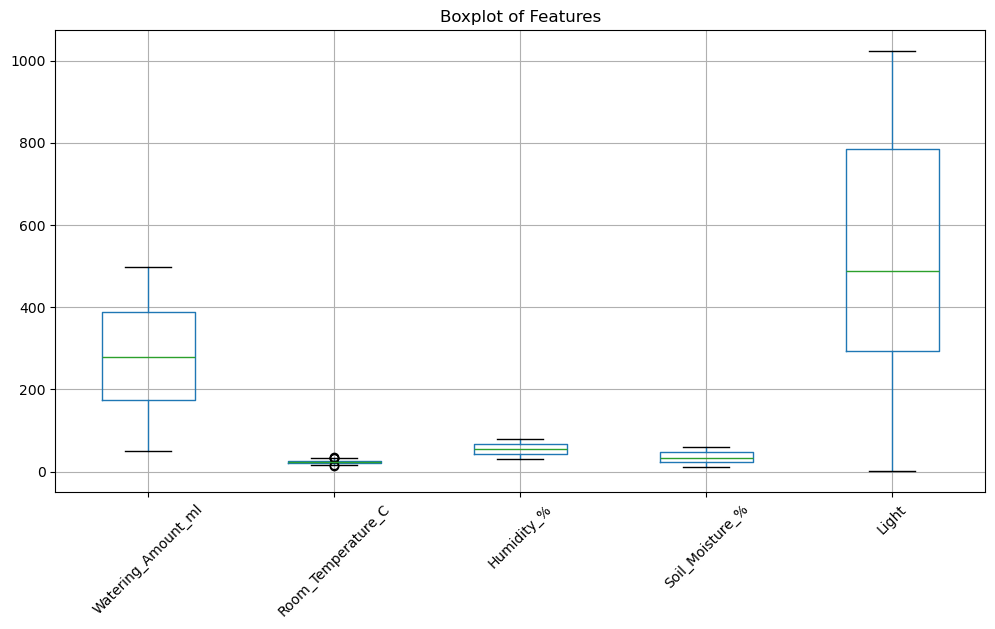

In [172]:
# Visualize the data in boxplots
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
df.boxplot()
plt.title('Boxplot of Features')
plt.xticks(rotation=45)
plt.show()

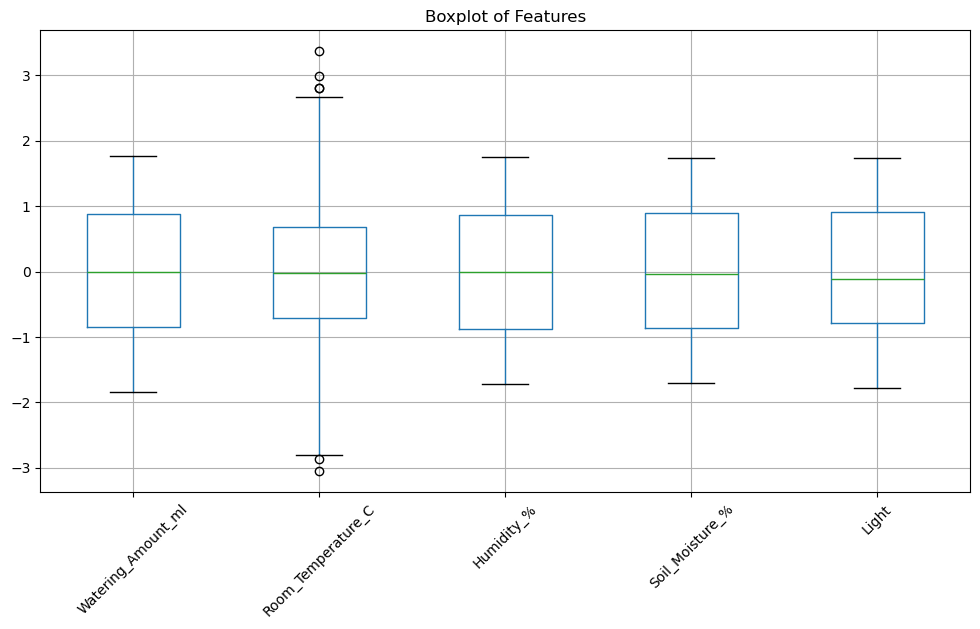

In [173]:
# Visualize the scaled data in boxplots
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
df_scaled.boxplot()
plt.title('Boxplot of Features')
plt.xticks(rotation=45)
plt.show()

No transformation needed

In [174]:
# count data points in train and test sets
print(f"Number of data points in training set: {len(X_train)}")
print(f"Number of data points in test set: {len(X_test)}")

Number of data points in training set: 800
Number of data points in test set: 200


In [175]:
# check the distribution of the target variable in the train and test sets
print("Distribution of target variable in training set:")
print(y_train.value_counts(normalize=True))
print("\nDistribution of target variable in test set:")
print(y_test.value_counts(normalize=True))

Distribution of target variable in training set:
Watering_Amount_ml
 0.479443    0.00750
 1.066060    0.00750
 0.447300    0.00750
-0.597361    0.00625
-1.103620    0.00625
              ...   
-1.151835    0.00125
 0.583909    0.00125
 0.198188    0.00125
-0.107174    0.00125
-1.521484    0.00125
Name: proportion, Length: 371, dtype: float64

Distribution of target variable in test set:
Watering_Amount_ml
 0.728554    0.020
-0.685755    0.015
-1.674165    0.015
-1.400946    0.015
-0.942903    0.015
             ...  
 1.749107    0.005
-0.573253    0.005
 0.591945    0.005
 0.776769    0.005
-1.794703    0.005
Name: proportion, Length: 161, dtype: float64


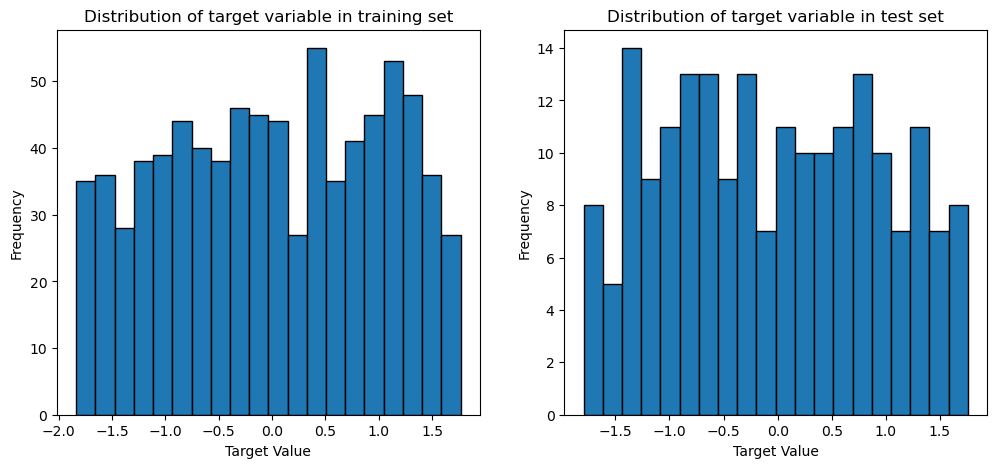

In [176]:
# visualize the distribution of the target variable in the train and test sets
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(y_train, bins=20, edgecolor='k')
plt.title("Distribution of target variable in training set")
plt.xlabel("Target Value")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(y_test, bins=20, edgecolor='k')
plt.title("Distribution of target variable in test set")
plt.xlabel("Target Value")
plt.ylabel("Frequency")

plt.show()

In [177]:
# split the data into training and testing sets
X = df_scaled.drop(columns=["Watering_Amount_ml"])
y = df_scaled["Watering_Amount_ml"]
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

In [178]:
X_train.columns

Index(['Room_Temperature_C', 'Humidity_%', 'Soil_Moisture_%', 'Light'], dtype='object')

In [179]:
# count data points in train, val and test sets
print(f"Number of data points in training set: {len(X_train)}")
print(f"Number of data points in validation set: {len(X_val)}")
print(f"Number of data points in test set: {len(X_test)}")

Number of data points in training set: 640
Number of data points in validation set: 160
Number of data points in test set: 200


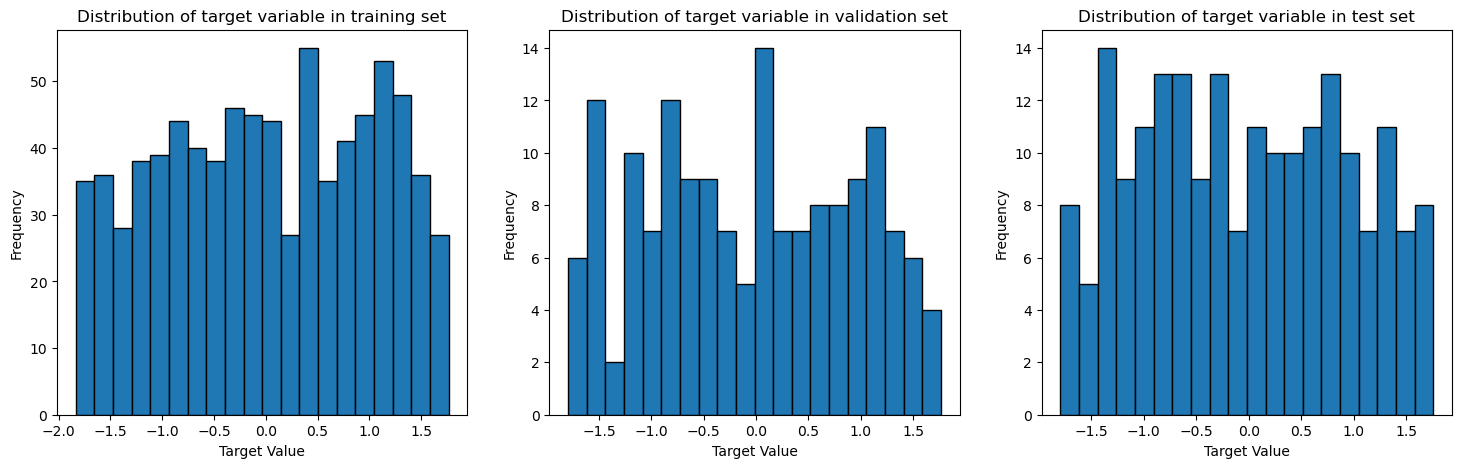

In [180]:
# plot the distribution of the target variable in the train, val and test sets
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.hist(y_train_val, bins=20, edgecolor='k')
plt.title("Distribution of target variable in training set")
plt.xlabel("Target Value")
plt.ylabel("Frequency")
plt.subplot(1, 3, 2)
plt.hist(y_val, bins=20, edgecolor='k')
plt.title("Distribution of target variable in validation set")
plt.xlabel("Target Value")
plt.ylabel("Frequency")
plt.subplot(1, 3, 3)
plt.hist(y_test, bins=20, edgecolor='k')
plt.title("Distribution of target variable in test set")
plt.xlabel("Target Value")
plt.ylabel("Frequency")
plt.show()

In [181]:
# discard the validation set and the train-val-test sets and use the cross validation to train the model
model = LinearRegression()
scores = cross_val_score(model, X_train_val, y_train_val, cv=5, scoring='r2')
print(f"Cross-validated R2 scores: {scores}")

Cross-validated R2 scores: [-0.01392915 -0.00161334 -0.01147163 -0.03409226 -0.01724027]


In [182]:
# Linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [183]:
y_pred = model.predict(X_train)
print(f"Predictions: {y_pred}")

Predictions: [ 0.02214448 -0.00441851 -0.02282292  0.05132865  0.0736303   0.08605612
  0.02530806  0.02396078  0.1245675   0.06185467  0.01194785  0.02538591
  0.02975042  0.08218675  0.05837161  0.0301107   0.0451807   0.01797053
 -0.02260877 -0.02012862  0.00606661  0.0548825  -0.00497614  0.02636565
  0.00279936 -0.04237592 -0.07211102 -0.05847053 -0.00862012  0.00615572
  0.04579538  0.01458334  0.0117035   0.07728258  0.04091213 -0.02247827
  0.04447544  0.00569718  0.02661037  0.05751554  0.0369658  -0.03300563
  0.00093196  0.03117474  0.06498547  0.05615598  0.12744345  0.01787454
 -0.01190807  0.09683516  0.03725134  0.04179066  0.03392329  0.01057461
  0.01298387  0.01636232  0.04848521  0.02211202  0.01467906 -0.0006094
  0.02320918 -0.01041415 -0.0667842  -0.02487695 -0.00130446 -0.02404484
  0.08392349 -0.01547131  0.05377098  0.05111996  0.09033828 -0.03742865
  0.08977463  0.01957052 -0.01865105 -0.0321839  -0.02125883  0.10016409
  0.08143521 -0.07191237  0.02797832  0

In [184]:
val_accuracy = model.score(X_val, y_val)
print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Accuracy: -0.0101


In [185]:
# Reapply cross-validation on the training set
cv_scores = cross_val_score(model, X_train, y_train, cv=5)
print(f"Cross-validation scores: {cv_scores}")

Cross-validation scores: [-0.02072935 -0.00995386 -0.03881979 -0.02983079 -0.02152749]


In [186]:
# Work the linear regression model using the cross validation scores
print(f"Mean CV score: {cv_scores.mean():.4f}")
print(f"Standard deviation of CV scores: {cv_scores.std():.4f}")

Mean CV score: -0.0242
Standard deviation of CV scores: 0.0097


In [187]:
X_train.columns

Index(['Room_Temperature_C', 'Humidity_%', 'Soil_Moisture_%', 'Light'], dtype='object')

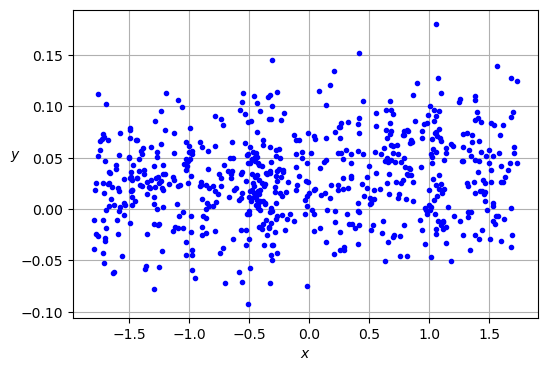

In [188]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X_train['Light'], y_pred, "b.")
plt.xlabel("$x$")
plt.ylabel("$y$", rotation=0)
plt.grid()
plt.show()

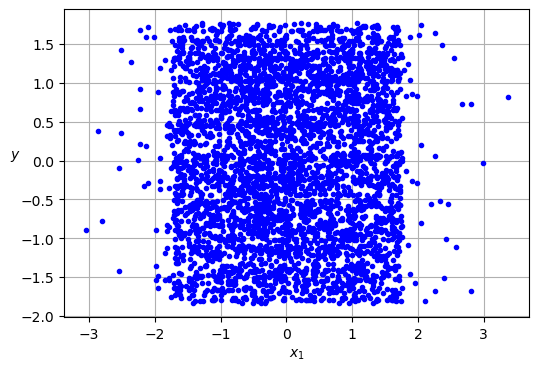

In [189]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.grid()
plt.show()

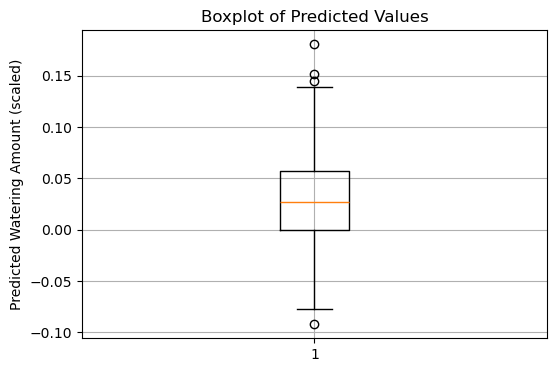

In [190]:
# box plot of y_pred
plt.figure(figsize=(6, 4))
plt.boxplot(y_pred)
plt.title("Boxplot of Predicted Values")
plt.ylabel("Predicted Watering Amount (scaled)")
plt.grid()
plt.show()

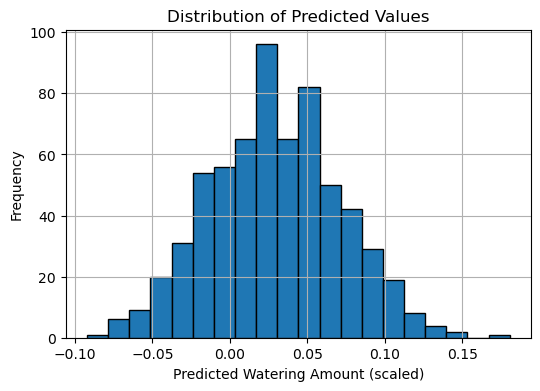

In [191]:
# plot the distribution of the predicted values
plt.figure(figsize=(6, 4))
plt.hist(y_pred, bins=20, edgecolor='k')
plt.title("Distribution of Predicted Values")
plt.xlabel("Predicted Watering Amount (scaled)")
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [192]:
# compute R2 score for y_pred and y_train
from sklearn.metrics import r2_score

r2 = r2_score(y_train, y_pred)
print(f"R2 Score: {r2:.4f}")

R2 Score: 0.0018


Try different models for regression

In [193]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Initialize and train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, oob_score=True)
rf_model.fit(X_train, y_train)

# Evaluate on the validation set
y_pred_val = rf_model.predict(X_val)
val_r2 = r2_score(y_val, y_pred_val)
val_mse = mean_squared_error(y_val, y_pred_val)

print(f"Random Forest Validation R-squared: {val_r2:.4f}")
print(f"Random Forest Validation MSE: {val_mse:.4f}")

# You can also check the OOB score, which is an internal cross-validation estimate
print(f"Random Forest OOB Score: {rf_model.oob_score_:.4f}")

Random Forest Validation R-squared: -0.1310
Random Forest Validation MSE: 1.0853
Random Forest OOB Score: -0.0992


The results are terrible, so the next approach is to include more features

In [194]:
df2 = data.copy()
df2

,Plant_ID,Height_cm,Leaf_Count,New_Growth_Count,Health_Notes,Watering_Amount_ml,Watering_Frequency_days,Sunlight_Exposure,Room_Temperature_C,Humidity_%,Fertilizer_Type,Fertilizer_Amount_ml,Pest_Presence,Pest_Severity,Soil_Moisture_%,Soil_Type,Health_Score
0,Sansevieria cylindrica,17.39,17,8,Yellowing leaves,205,3,3h direct morning sun,21.7,77.5,Organic,82,Fungus gnats,Moderate,51.9,Clay,1
1,Aloe vera,9.84,31,9,NaN,191,1,3h direct morning sun,22.6,68.9,NaN,91,Aphids,Low,28.2,Loamy,2
2,Ficus lyrata,19.82,40,8,Brittle leaves,477,5,Indirect light all day,17.2,44.3,Liquid feed,90,NaN,High,13.6,Sandy,1
3,Monstera deliciosa,37.08,11,1,New bud,207,1,Low light corner,25.0,72.2,Compost,76,Fungus gnats,Low,38.4,Sandy,4
4,Ficus lyrata,2.96,26,3,Wilting,465,2,Filtered sunlight through curtain,23.2,51.6,Compost,37,Fungus gnats,Low,37.9,Peaty,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Sansevieria cylindrica,32.27,16,7,Leaf drop,370,4,6h full sun,32.4,58.0,Compost,96,Fungus gnats,High,31.7,Sandy,3
996,Schefflera arboricola,26.60,44,0,Yellowing leaves,91,3,Filtered sunlight through curtain,24.3,39.4,Compost,14,Spider mites,Low,32.9,Silty,4
997,Monstera deliciosa,9.69,13,0,NaN,134,4,3h direct morning sun,26.4,52.4,NaN,80,Spider mites,Low,58.5,Peaty,5
998,Epipremnum aureum,23.54,16,7,Brittle leaves,442,3,3h direct morning sun,18.7,60.1,Organic,97,Fungus gnats,Moderate,24.8,Loamy,2


In [195]:
# preprocess the data by checking for missing values
df2.isnull().sum()

Plant_ID                     0
Height_cm                    0
Leaf_Count                   0
New_Growth_Count             0
Health_Notes               118
Watering_Amount_ml           0
Watering_Frequency_days      0
Sunlight_Exposure            0
Room_Temperature_C           0
Humidity_%                   0
Fertilizer_Type            195
Fertilizer_Amount_ml         0
Pest_Presence              202
Pest_Severity              242
Soil_Moisture_%              0
Soil_Type                    0
Health_Score                 0
dtype: int64

In [196]:
# Change the data type of the columns to numeric if possible
numeric_columns = df2.columns[df2.dtypes == 'object']
numeric_columns

Index(['Plant_ID', 'Health_Notes', 'Sunlight_Exposure', 'Fertilizer_Type',
       'Pest_Presence', 'Pest_Severity', 'Soil_Type'],
      dtype='object')

In [197]:
# drop the plant Id to treat all the plants as one group
df2 = df2.drop(columns=['Plant_ID'])
df2

,Height_cm,Leaf_Count,New_Growth_Count,Health_Notes,Watering_Amount_ml,Watering_Frequency_days,Sunlight_Exposure,Room_Temperature_C,Humidity_%,Fertilizer_Type,Fertilizer_Amount_ml,Pest_Presence,Pest_Severity,Soil_Moisture_%,Soil_Type,Health_Score
0,17.39,17,8,Yellowing leaves,205,3,3h direct morning sun,21.7,77.5,Organic,82,Fungus gnats,Moderate,51.9,Clay,1
1,9.84,31,9,NaN,191,1,3h direct morning sun,22.6,68.9,NaN,91,Aphids,Low,28.2,Loamy,2
2,19.82,40,8,Brittle leaves,477,5,Indirect light all day,17.2,44.3,Liquid feed,90,NaN,High,13.6,Sandy,1
3,37.08,11,1,New bud,207,1,Low light corner,25.0,72.2,Compost,76,Fungus gnats,Low,38.4,Sandy,4
4,2.96,26,3,Wilting,465,2,Filtered sunlight through curtain,23.2,51.6,Compost,37,Fungus gnats,Low,37.9,Peaty,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,32.27,16,7,Leaf drop,370,4,6h full sun,32.4,58.0,Compost,96,Fungus gnats,High,31.7,Sandy,3
996,26.60,44,0,Yellowing leaves,91,3,Filtered sunlight through curtain,24.3,39.4,Compost,14,Spider mites,Low,32.9,Silty,4
997,9.69,13,0,NaN,134,4,3h direct morning sun,26.4,52.4,NaN,80,Spider mites,Low,58.5,Peaty,5
998,23.54,16,7,Brittle leaves,442,3,3h direct morning sun,18.7,60.1,Organic,97,Fungus gnats,Moderate,24.8,Loamy,2


Preprocess Health_Notes

In [198]:
df2['Health_Notes'].isnull().sum()

118

In [199]:
# impute the missing values in the Health_Notes column with the most frequent value
most_frequent_value = df2['Health_Notes'].mode()[0]
df2['Health_Notes'].fillna(most_frequent_value, inplace=True)
df2['Health_Notes'].isnull().sum()

C:\Users\youss\AppData\Local\Temp\ipykernel_12832\1337134530.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['Health_Notes'].fillna(most_frequent_value, inplace=True)


0

In [200]:
df2['Health_Notes'].unique()

array(['Yellowing leaves', 'New bud', 'Brittle leaves', 'Wilting',
       'Strong stem', 'Dark green color', 'Leaf drop'], dtype=object)

In [201]:
# Translate the Health_Notes column to numeric values using one-hot encoding
# 'Yellowing leaves', 'New bud', 'Brittle leaves', 'Wilting',
#        'Strong stem', 'Dark green color', 'Leaf drop'
# from worst to best health condition
health_mapping = {
    'Yellowing leaves': 3,
    'New bud': 6,
    'Brittle leaves': 2,
    'Wilting': 0,
    'Strong stem': 4,
    'Dark green color': 5,
    'Leaf drop': 1
}
df2['Health_Notes'] = df2['Health_Notes'].map(health_mapping)
df2['Health_Notes'].unique()

array([3, 6, 2, 0, 4, 5, 1], dtype=int64)

In [202]:
df2.head()

,Height_cm,Leaf_Count,New_Growth_Count,Health_Notes,Watering_Amount_ml,Watering_Frequency_days,Sunlight_Exposure,Room_Temperature_C,Humidity_%,Fertilizer_Type,Fertilizer_Amount_ml,Pest_Presence,Pest_Severity,Soil_Moisture_%,Soil_Type,Health_Score
0,17.39,17,8,3,205,3,3h direct morning sun,21.7,77.5,Organic,82,Fungus gnats,Moderate,51.9,Clay,1
1,9.84,31,9,6,191,1,3h direct morning sun,22.6,68.9,NaN,91,Aphids,Low,28.2,Loamy,2
2,19.82,40,8,2,477,5,Indirect light all day,17.2,44.3,Liquid feed,90,NaN,High,13.6,Sandy,1
3,37.08,11,1,6,207,1,Low light corner,25.0,72.2,Compost,76,Fungus gnats,Low,38.4,Sandy,4
4,2.96,26,3,0,465,2,Filtered sunlight through curtain,23.2,51.6,Compost,37,Fungus gnats,Low,37.9,Peaty,1


In [203]:
df2['Sunlight_Exposure']

0                  3h direct morning sun
1                  3h direct morning sun
2                 Indirect light all day
3                       Low light corner
4      Filtered sunlight through curtain
                     ...                
995                          6h full sun
996    Filtered sunlight through curtain
997                3h direct morning sun
998                3h direct morning sun
999                          6h full sun
Name: Sunlight_Exposure, Length: 1000, dtype: object

In [204]:
# translate sunlight exposure to numeric values by mapping the categories to their corresponding numeric ranges
light_mapping = {
    "Low light corner": (0, 200),
    "Indirect light all day": (200, 450),
    "Filtered sunlight through curtain": (350, 600),
    "3h direct morning sun": (600, 850),
    "6h full sun": (800, 1023)
}

rng = np.random.default_rng(42)

df2["Light"] = df2["Sunlight_Exposure"].apply(
    lambda value: rng.integers(
        light_mapping[value][0],
        light_mapping[value][1] + 1
    )
)

print(df2[["Sunlight_Exposure", "Light"]].head(20))
print(df2.groupby("Sunlight_Exposure")["Light"].describe())

                    Sunlight_Exposure  Light
0               3h direct morning sun    622
1               3h direct morning sun    794
2              Indirect light all day    364
3                    Low light corner     88
4   Filtered sunlight through curtain    458
5                    Low light corner    172
6               3h direct morning sun    621
7   Filtered sunlight through curtain    525
8                         6h full sun    845
9   Filtered sunlight through curtain    373
10                   Low light corner    105
11             Indirect light all day    444
12                        6h full sun    964
13                   Low light corner    152
14                        6h full sun    960
15  Filtered sunlight through curtain    547
16              3h direct morning sun    728
17                   Low light corner     25
18             Indirect light all day    410
19  Filtered sunlight through curtain    463
                                   count        mean   

In [205]:
df2.drop(columns=['Sunlight_Exposure'], inplace=True)
df2.head()

,Height_cm,Leaf_Count,New_Growth_Count,Health_Notes,Watering_Amount_ml,Watering_Frequency_days,Room_Temperature_C,Humidity_%,Fertilizer_Type,Fertilizer_Amount_ml,Pest_Presence,Pest_Severity,Soil_Moisture_%,Soil_Type,Health_Score,Light
0,17.39,17,8,3,205,3,21.7,77.5,Organic,82,Fungus gnats,Moderate,51.9,Clay,1,622
1,9.84,31,9,6,191,1,22.6,68.9,NaN,91,Aphids,Low,28.2,Loamy,2,794
2,19.82,40,8,2,477,5,17.2,44.3,Liquid feed,90,NaN,High,13.6,Sandy,1,364
3,37.08,11,1,6,207,1,25.0,72.2,Compost,76,Fungus gnats,Low,38.4,Sandy,4,88
4,2.96,26,3,0,465,2,23.2,51.6,Compost,37,Fungus gnats,Low,37.9,Peaty,1,458


In [206]:
# drop Fertilizer_Type, Fertilizer_Amount_ml, Pest_Presence, Pest_Severity, Health_Score because they are not relevant to the model
df2.drop(columns=['Fertilizer_Type', 'Fertilizer_Amount_ml', 'Pest_Presence', 'Pest_Severity', 'Health_Score'], inplace=True)
df2.head()

,Height_cm,Leaf_Count,New_Growth_Count,Health_Notes,Watering_Amount_ml,Watering_Frequency_days,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Soil_Type,Light
0,17.39,17,8,3,205,3,21.7,77.5,51.9,Clay,622
1,9.84,31,9,6,191,1,22.6,68.9,28.2,Loamy,794
2,19.82,40,8,2,477,5,17.2,44.3,13.6,Sandy,364
3,37.08,11,1,6,207,1,25.0,72.2,38.4,Sandy,88
4,2.96,26,3,0,465,2,23.2,51.6,37.9,Peaty,458


In [207]:
# One hot encoding for the soil type column
soil_dummies = pd.get_dummies(df2['Soil_Type'], prefix='Soil', dtype=int)
df2 = pd.concat([df2, soil_dummies], axis=1)
df2 = df2.drop(columns=['Soil_Type'])

In [208]:
print(df2)

     Height_cm  Leaf_Count  New_Growth_Count  Health_Notes  \
0        17.39          17                 8             3   
1         9.84          31                 9             6   
2        19.82          40                 8             2   
3        37.08          11                 1             6   
4         2.96          26                 3             0   
..         ...         ...               ...           ...   
995      32.27          16                 7             1   
996      26.60          44                 0             3   
997       9.69          13                 0             6   
998      23.54          16                 7             2   
999      37.90          30                 4             5   

     Watering_Amount_ml  Watering_Frequency_days  Room_Temperature_C  \
0                   205                        3                21.7   
1                   191                        1                22.6   
2                   477                

In [209]:
df2.columns

Index(['Height_cm', 'Leaf_Count', 'New_Growth_Count', 'Health_Notes',
       'Watering_Amount_ml', 'Watering_Frequency_days', 'Room_Temperature_C',
       'Humidity_%', 'Soil_Moisture_%', 'Light', 'Soil_Chalky', 'Soil_Clay',
       'Soil_Loamy', 'Soil_Peaty', 'Soil_Sandy', 'Soil_Silty'],
      dtype='object')

In [210]:
# Rename the columns
df2.rename(columns={
    'Humidity_%': 'Humidity',
    'Room_Temperature_C': 'Temperature',
    'Soil_Moisture_%': 'Soil_Moisture',
}, inplace=True)

In [211]:
df2.head()

,Height_cm,Leaf_Count,New_Growth_Count,Health_Notes,Watering_Amount_ml,Watering_Frequency_days,Temperature,Humidity,Soil_Moisture,Light,Soil_Chalky,Soil_Clay,Soil_Loamy,Soil_Peaty,Soil_Sandy,Soil_Silty
0,17.39,17,8,3,205,3,21.7,77.5,51.9,622,0,1,0,0,0,0
1,9.84,31,9,6,191,1,22.6,68.9,28.2,794,0,0,1,0,0,0
2,19.82,40,8,2,477,5,17.2,44.3,13.6,364,0,0,0,0,1,0
3,37.08,11,1,6,207,1,25.0,72.2,38.4,88,0,0,0,0,1,0
4,2.96,26,3,0,465,2,23.2,51.6,37.9,458,0,0,0,1,0,0


In [212]:
# check for null
df2.isnull().sum()

Height_cm                  0
Leaf_Count                 0
New_Growth_Count           0
Health_Notes               0
Watering_Amount_ml         0
Watering_Frequency_days    0
Temperature                0
Humidity                   0
Soil_Moisture              0
Light                      0
Soil_Chalky                0
Soil_Clay                  0
Soil_Loamy                 0
Soil_Peaty                 0
Soil_Sandy                 0
Soil_Silty                 0
dtype: int64

In [213]:
# check for distribution of the each column in the data using boxplots
import matplotlib.pyplot as plt
# plt.figure(figsize=(12, 6))
# df2.boxplot()
# plt.show()
# This is not good 